In [30]:
# 1. استدعاء المكتبات البرمجية اللازمة للتحليل والإحصاء
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 2. قراءة ملف البيانات النظيف
df = pd.read_csv('price_clean.csv')

# 3. عرض الأسطر الخمسة الأولى للتأكد من قراءة البيانات بنجاح
df.head()

,obj_regio1,obj_newlyConst,obj_yearConstructed,obj_firingTypes,obj_cellar,obj_houseNumber,obj_livingSpace,geo_krs,obj_condition,obj_street,geo_plz,obj_noRooms,obj_telekomInternetProductAvailable,obj_barrierFree,obj_regio3,obj_livingSpaceRange,obj_telekomUploadSpeed,obj_telekomDownloadSpeed,obj_purchasePrice,obj_purchasePrice_per_qm
0,Niedersachsen,n,2013.0,gas,n,no_information,170.0,Verden_Kreis,well_kept,no_information,28832.0,6.0,True,n,Achim,5.0,40.0,100.0,549000.0,3229.411765
1,Niedersachsen,n,1909.0,oil,n,no_information,170.0,Hannover_Kreis,well_kept,no_information,30900.0,6.0,True,n,Wedemark,5.0,2.4,16.0,460000.0,2705.882353
2,Niedersachsen,n,1969.0,district_heating,y,no_information,116.0,Celle_Kreis,well_kept,no_information,29353.0,6.0,True,n,other,2.0,10.0,50.0,148500.0,1280.172414
3,Niedersachsen,y,2020.0,NaN,n,no_information,133.0,Helmstedt_Kreis,first_time_use,no_information,38364.0,4.0,True,n,Schöningen,3.0,40.0,100.0,248400.0,1867.669173
4,Niedersachsen,n,2000.0,district_heating,y,no_information,136.0,Wolfsburg,well_kept,no_information,38446.0,5.0,True,y,other,3.0,2.4,16.0,369000.0,2713.235294


In [31]:
import pandas as pd

# 1. قراءة البيانات
df = pd.read_csv('price_clean.csv')

# 2. تحسين مخرج الإحصاء الوصفي للأرقام (تنظيف الفواصل وتقريبها)
print("==================================================")
print("   1. SUMMARY STATISTICS FOR NUMERICAL VARIABLES  ")
print("==================================================")
# غيّرنا أسماء الأعمدة لتكون احترافية في الطباعة
numerical_cols = {
    'obj_purchasePrice': 'Price (€)', 
    'obj_livingSpace': 'Living Space (m²)', 
    'obj_noRooms': 'Rooms'
}
summary = df[list(numerical_cols.keys())].describe().round(1)
summary.rename(columns=numerical_cols, inplace=True)
print(summary.loc[['mean', '50%', 'std', 'min', 'max']]) # اخترنا الأهم فقط لتقليل التشتت

print("\n==================================================")
print("   2. PERCENTAGE OF PROPERTY CONDITIONS          ")
print("==================================================")
# حساب النسبة المئوية وإضافة رمز % للشكل الجمالي
condition_pct = (df['obj_condition'].value_counts(normalize=True) * 100).round(1)
condition_df = pd.DataFrame({'Percentage': condition_pct.astype(str) + '%'})
print(condition_df)

   1. SUMMARY STATISTICS FOR NUMERICAL VARIABLES  
      Price (€)  Living Space (m²)  Rooms
mean   356673.3              193.6    6.6
50%    304903.0              161.0    6.0
std    252100.1              121.2    3.5
min     25000.0               30.0    1.0
max   3752000.0             2940.0   53.0

   2. PERCENTAGE OF PROPERTY CONDITIONS          
                                   Percentage
obj_condition                                
well_kept                               34.5%
no_information                          30.3%
need_of_renovation                       8.0%
first_time_use                           7.8%
mint_condition                           7.5%
modernized                               6.0%
refurbished                              2.5%
fully_renovated                          2.4%
first_time_use_after_refurbishment       0.6%
negotiable                               0.3%
ripe_for_demolition                      0.1%


In [32]:
import pandas as pd

# قراءة البيانات
df = pd.read_csv('price_clean.csv')

print("==================================================")
print("   1. TEMPORAL VARIABLE (Year Constructed)        ")
print("==================================================")
# استخدام الوسيط والقيم الصغرى والعظمى بدلاً من المتوسط
year_stats = df['obj_yearConstructed'].describe().loc[['50%', 'min', 'max']]
print(f"Median Year Built: {year_stats['50%']}")
print(f"Oldest Property:   {year_stats['min']}")
print(f"Newest Property:   {year_stats['max']}\n")

print("==================================================")
print("   2. DERIVED VARIABLE (Price per m²)            ")
print("==================================================")
# حساب متوسط وسيط سعر المتر المربع لأهميته في السوق
price_per_qm_stats = df['obj_purchasePrice_per_qm'].describe().loc[['mean', '50%']].round(2)
print(price_per_qm_stats)

print("\n==================================================")
print("   3. TECHNICAL VARIABLES (Internet Speeds)       ")
print("==================================================")
# حساب الإحصاءات مع إظهار عدد القيم المفقودة لكل عمود
internet_summary = df[['obj_telekomUploadSpeed', 'obj_telekomDownloadSpeed']].describe().round(1)
print(internet_summary.loc[['mean', '50%', 'count']])
print(f"Missing Upload Values: {df['obj_telekomUploadSpeed'].isna().sum()}")

   1. TEMPORAL VARIABLE (Year Constructed)        
Median Year Built: 1974.0
Oldest Property:   1496.0
Newest Property:   2021.0

   2. DERIVED VARIABLE (Price per m²)            
mean    1961.72
50%     1890.30
Name: obj_purchasePrice_per_qm, dtype: float64

   3. TECHNICAL VARIABLES (Internet Speeds)       
       obj_telekomUploadSpeed  obj_telekomDownloadSpeed
mean                     21.1                      58.6
50%                      10.0                      50.0
count                  3905.0                    3905.0
Missing Upload Values: 933


In [16]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"(Numerisch): {numerical_cols}\n")
print(f"(Nominal): {categorical_cols}")

(Numerisch): ['obj_yearConstructed', 'obj_livingSpace', 'geo_plz', 'obj_noRooms', 'obj_livingSpaceRange', 'obj_telekomUploadSpeed', 'obj_telekomDownloadSpeed', 'obj_purchasePrice', 'obj_purchasePrice_per_qm']

(Nominal): ['obj_regio1', 'obj_newlyConst', 'obj_firingTypes', 'obj_cellar', 'obj_houseNumber', 'geo_krs', 'obj_condition', 'obj_street', 'obj_telekomInternetProductAvailable', 'obj_barrierFree', 'obj_regio3']


C:\Users\Yasser Nourallah\AppData\Local\Temp\ipykernel_12896\240419728.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


--- 🔗 جدول ارتباط الأعمدة الرقمية بعمود السعر Target ---
                          Pearson (Linear)  Spearman (Rank)
geo_plz                          -0.032617        -0.075197
obj_livingSpace                   0.631197         0.496689
obj_livingSpaceRange              0.451615         0.490814
obj_noRooms                       0.468424         0.289894
obj_purchasePrice                 1.000000         1.000000
obj_purchasePrice_per_qm          0.471710         0.616479
obj_telekomDownloadSpeed          0.055874         0.051078
obj_telekomUploadSpeed            0.053277         0.052941
obj_yearConstructed               0.061064         0.285609


<function matplotlib.pyplot.show(close=None, block=None)>

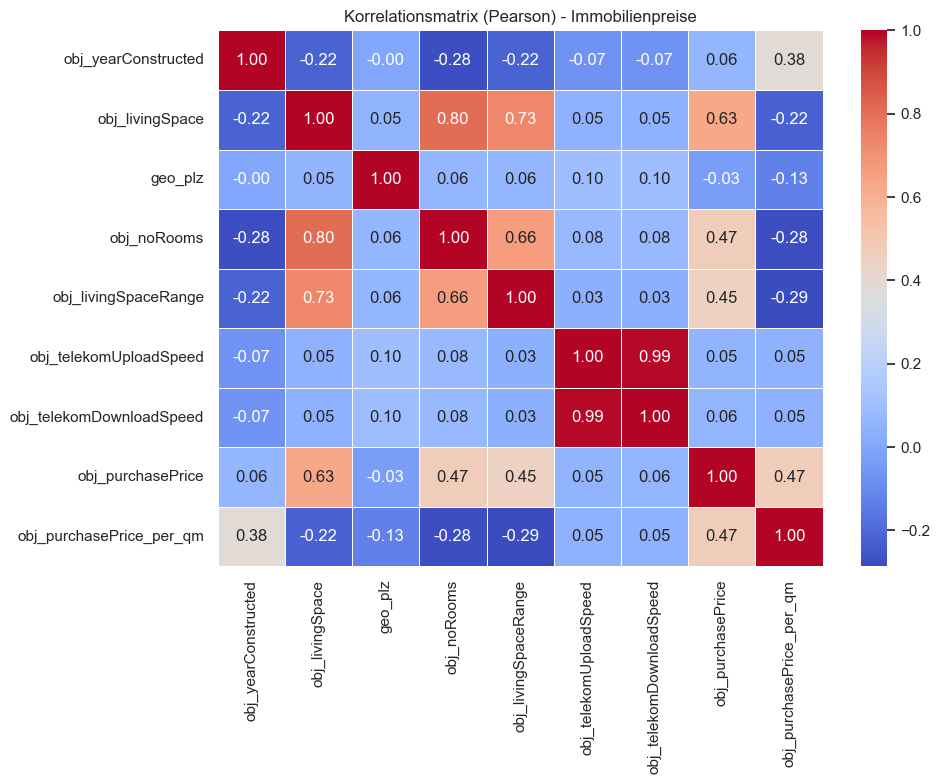

In [17]:
pearson_corr = df[numerical_cols].corr(method='pearson')['obj_purchasePrice'].sort_values(ascending=False)
spearman_corr = df[numerical_cols].corr(method='spearman')['obj_purchasePrice'].sort_values(ascending=False)
correlation_summary = pd.DataFrame({
    'Pearson (Linear)' : pearson_corr,
    'Spearman (Rank)' :spearman_corr
})
print("--- 🔗 جدول ارتباط الأعمدة الرقمية بعمود السعر Target ---")
print(correlation_summary)

plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(method='pearson'), annot=True ,cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Korrelationsmatrix (Pearson) - Immobilienpreise')
plt.tight_layout()
plt.show

C:\Users\Yasser Nourallah\AppData\Local\Temp\ipykernel_12896\1922206320.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_correlations.values, y=price_correlations.index, palette='coolwarm')


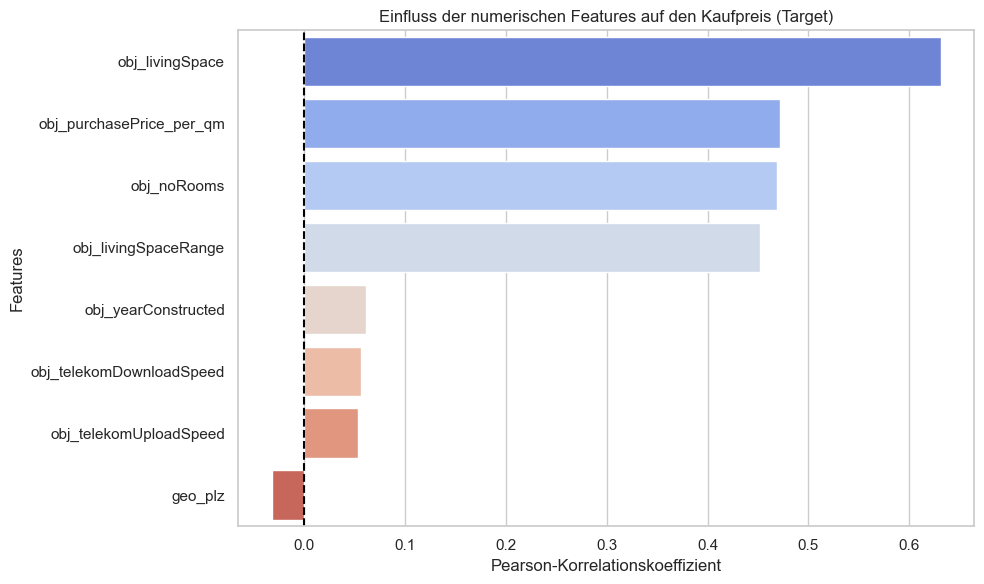

In [18]:
# 1. عزل ارتباط الأعمدة مع السعر فقط وحذف ارتباط السعر مع نفسه
price_correlations = df[numerical_cols].corr(method='pearson')['obj_purchasePrice'].drop('obj_purchasePrice').sort_values(ascending=False)

# 2. رسم المخطط العمودي
plt.figure(figsize=(10, 6))
sns.barplot(x=price_correlations.values, y=price_correlations.index, palette='coolwarm')
plt.axvline(x=0, color='black', linestyle='--') # خط مرجعي عند الصفر
plt.title('Einfluss der numerischen Features auf den Kaufpreis (Target)')
plt.xlabel('Pearson-Korrelationskoeffizient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

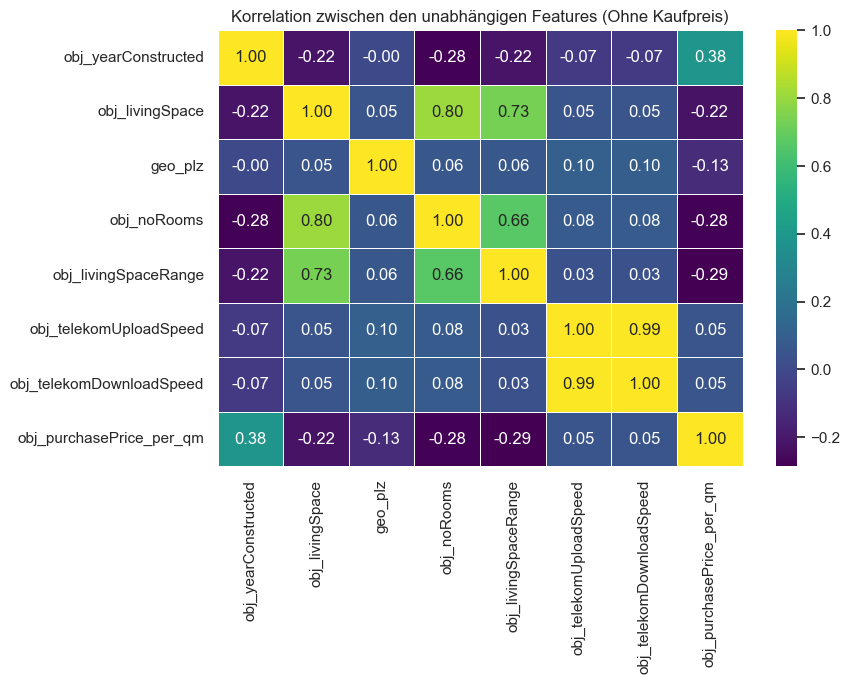

In [19]:
# 1. إنشاء قائمة بالأعمدة الرقمية بدون عمود السعر
features_only = [col for col in numerical_cols if col != 'obj_purchasePrice']

# 2. حساب مصفوفة الارتباط للميزات فقط
features_corr = df[features_only].corr(method='pearson')

# 3. رسم الخارطة الحرارية للعلاقات بين الميزات
plt.figure(figsize=(9, 7))
sns.heatmap(features_corr, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title('Korrelation zwischen den unabhängigen Features (Ohne Kaufpreis)')
plt.tight_layout()
plt.show()

### 1. Analysis of Property Condition (obj_condition)

C:\Users\Yasser Nourallah\AppData\Local\Temp\ipykernel_12896\1113454259.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


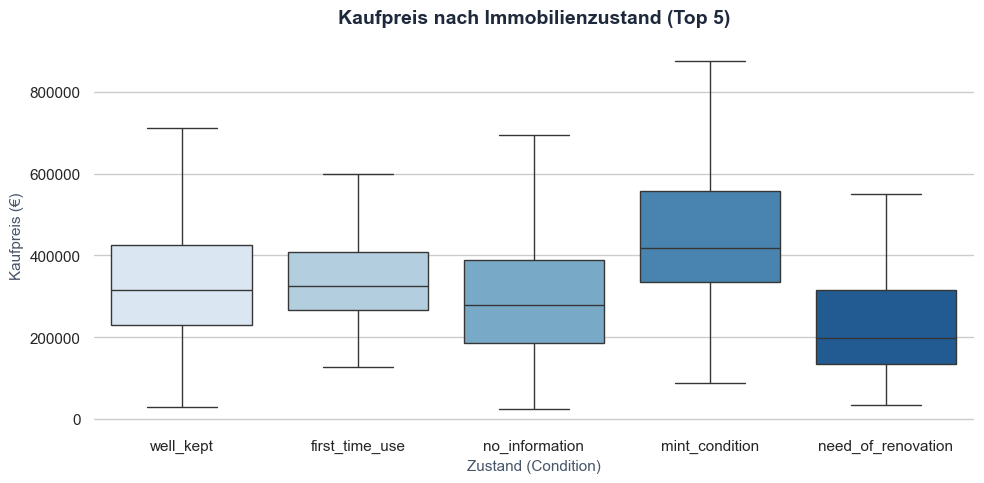

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. إعداد اللوحة بخلفية بيضاء ونظيفة
plt.figure(figsize=(10, 5), dpi=100)
sns.set_theme(style="whitegrid")

# 2. رسم البوكس بلوت لأعلى 5 فئات مكررة وبدون القيم الشاذة المتطرفة
top_frequent = df['obj_condition'].value_counts().head(5).index

sns.boxplot(
    data=df[df['obj_condition'].isin(top_frequent)], 
    x='obj_condition', 
    y='obj_purchasePrice', 
    palette='Blues', 
    showfliers=False
)

# ⭐ 3. السطر السحري لتوحيد المحور وعرض الأرقام كاملة وصريحة (مثل 200000)
plt.ticklabel_format(style='plain', axis='y')

# 4. العناوين الأنيقة والمحاور
plt.title('Kaufpreis nach Immobilienzustand (Top 5)', fontsize=14, fontweight='bold', pad=15, color='#1e293b')
plt.xlabel('Zustand (Condition)', fontsize=11, color='#475569')
plt.ylabel('Kaufpreis (€)', fontsize=11, color='#475569')

sns.despine(left=True, bottom=True) # حذف الإطار الخارجي لشكل عصري
plt.tight_layout()
plt.show()

### 2. Analysis of Heating Types (obj_firingTypes)

C:\Users\Yasser Nourallah\AppData\Local\Temp\ipykernel_12896\483463966.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


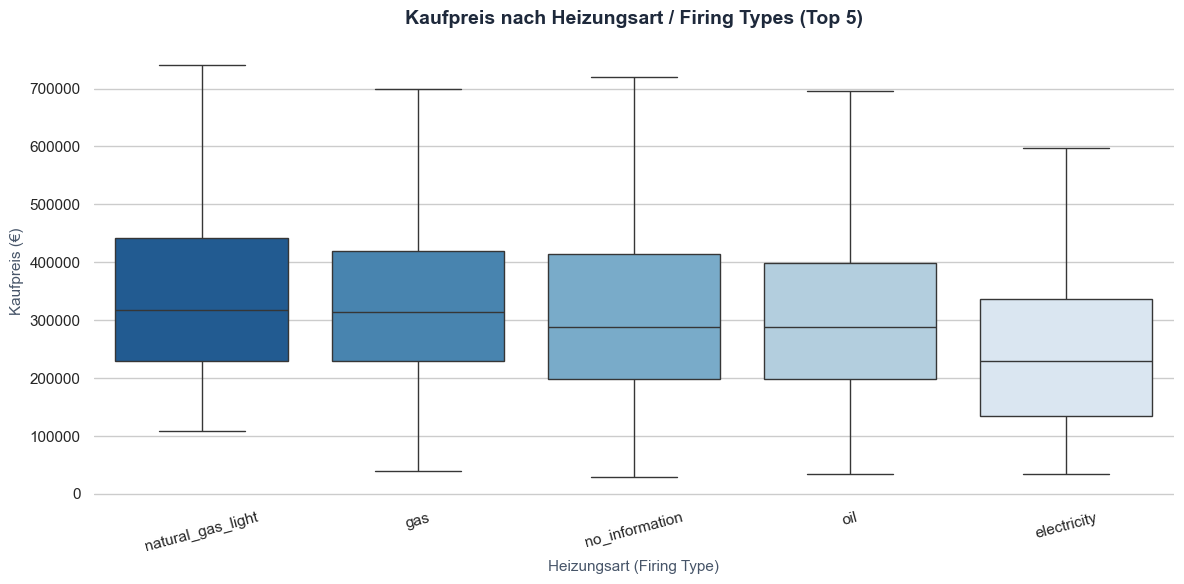

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6), dpi=100)
sns.set_theme(style="whitegrid")

top_firing = df['obj_firingTypes'].value_counts().head(5).index

# الخطوة السحرية: تصفية البيانات ثم ترتيب الفئات بناءً على "وسيط السعر" تنازلياً
# لكي تظهر الفئة الأغلى في أول الرسمة على اليسار
ordered_firing = (
    df[df['obj_firingTypes'].isin(top_firing)]
    .groupby('obj_firingTypes')['obj_purchasePrice']
    .median()
    .sort_values(ascending=False)
    .index
)

# 3. رسم البوكس بلوت مع تطبيق الترتيب الجديد وعكس الألوان (_r)
sns.boxplot(
    data=df[df['obj_firingTypes'].isin(top_firing)], 
    x='obj_firingTypes', 
    y='obj_purchasePrice', 
    order=ordered_firing,  # إجبار بايثون على هذا الترتيب السعري
    palette='Blues_r',     # حرف _r يعني المعكوس (الأغمق للأغلى والأفتح للأرخص)
    showfliers=False
)

# 4. توحيد المحور الصادي لإظهار الأرقام صريحة (مثل 200000)
plt.ticklabel_format(style='plain', axis='y')

# 5. العناوين الأنيقة والمحاور (بالألمانية والانكليزية)
plt.title('Kaufpreis nach Heizungsart / Firing Types (Top 5)', fontsize=14, fontweight='bold', pad=15, color='#1e293b')
plt.xlabel('Heizungsart (Firing Type)', fontsize=11, color='#475569')
plt.ylabel('Kaufpreis (€)', fontsize=11, color='#475569')

# تدوير أسماء الفئات قليلاً لكي لا تتداخل الكلمات إذا كانت طويلة
plt.xticks(rotation=15)

sns.despine(left=True, bottom=True) # حذف الإطار الخارجي لشكل عصري
plt.tight_layout()
plt.show()

### 3. Analysis of Cities (obj_regio2)

C:\Users\Yasser Nourallah\AppData\Local\Temp\ipykernel_12896\1444600398.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


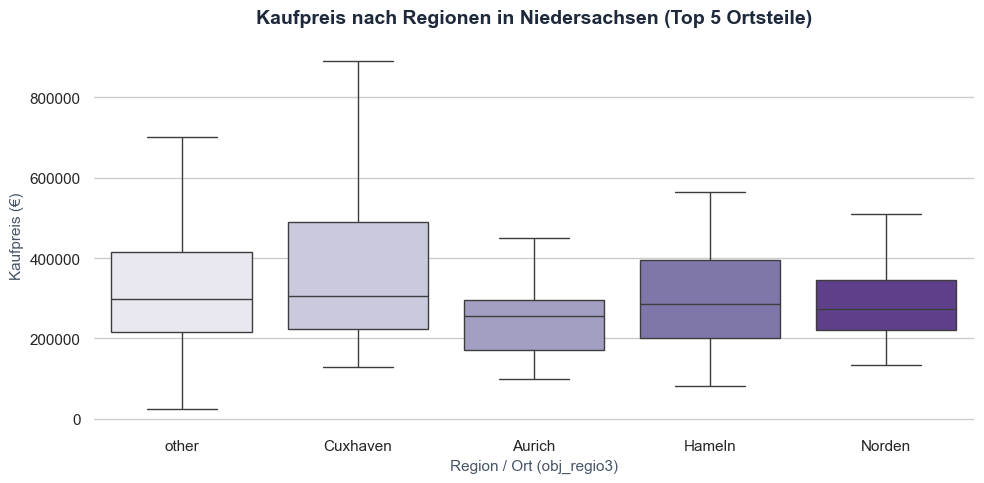

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. إعداد اللوحة بخلفية بيضاء ونظيفة
plt.figure(figsize=(10, 5), dpi=100)
sns.set_theme(style="whitegrid")

# 2. فلترة أعلى 5 مناطق (obj_regio3) تحتوي على أكثر عدد عقارات
top_regions = df['obj_regio3'].value_counts().head(5).index

# 3. رسم البوكس بلوت للأحياء الخمسة الأكبر
sns.boxplot(
    data=df[df['obj_regio3'].isin(top_regions)], 
    x='obj_regio3', 
    y='obj_purchasePrice', 
    palette='Purples', # اللون البنفسجي الملكي الأنيق
    showfliers=False
)

# 4. التنسيق والعناوين باللغة الألمانية
plt.title('Kaufpreis nach Regionen in Niedersachsen (Top 5 Ortsteile)', fontsize=14, fontweight='bold', pad=15, color='#1e293b')
plt.xlabel('Region / Ort (obj_regio3)', fontsize=11, color='#475569')
plt.ylabel('Kaufpreis (€)', fontsize=11, color='#475569')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

C:\Users\Yasser Nourallah\AppData\Local\Temp\ipykernel_12896\1329981077.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


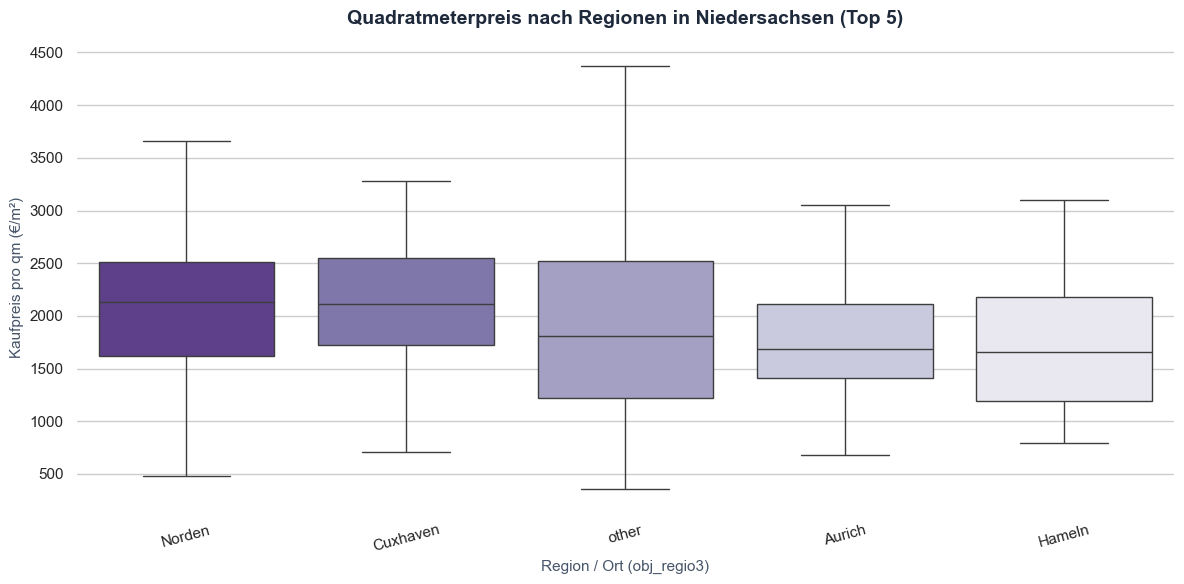

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. إعداد اللوحة بخلفية بيضاء ونظيفة
plt.figure(figsize=(12, 6), dpi=100)
sns.set_theme(style="whitegrid")

# 2. فلترة أعلى 5 مناطق (obj_regio3) تحتوي على أكثر عدد عقارات
top_regions = df['obj_regio3'].value_counts().head(5).index

# ⭐ خطوة ذكية: ترتيب المناطق بناءً على "وسيط سعر المتر المربع" تنازلياً
# لكي تظهر المنطقة الأغلى على اليسار باللون الأغمق
ordered_regions = (
    df[df['obj_regio3'].isin(top_regions)]
    .groupby('obj_regio3')['obj_purchasePrice_per_qm']
    .median()
    .sort_values(ascending=False)
    .index
)

# 3. رسم البوكس بلوت لمقارنة سعر المتر المربع (obj_purchasePrice_per_qm)
sns.boxplot(
    data=df[df['obj_regio3'].isin(top_regions)], 
    x='obj_regio3', 
    y='obj_purchasePrice_per_qm',  # التعديل الأساسي هنا
    order=ordered_regions,          # تطبيق الترتيب السعري الذكي
    palette='Purples_r',           # التدرج الملكي المعكوس (الأغمق للأغلى)
    showfliers=False
)

# 4. توحيد المحور الصادي لإظهار الأرقام صريحة وبسيطة
plt.ticklabel_format(style='plain', axis='y')

# 5. التنسيق والعناوين المحدثة باللغة الألمانية والإنجليزية
plt.title('Quadratmeterpreis nach Regionen in Niedersachsen (Top 5)', fontsize=14, fontweight='bold', pad=15, color='#1e293b')
plt.xlabel('Region / Ort (obj_regio3)', fontsize=11, color='#475569')
plt.ylabel('Kaufpreis pro qm (€/m²)', fontsize=11, color='#475569')

# تدوير أسماء المدن قليلاً لضمان عدم التداخل البصري
plt.xticks(rotation=15)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Value Counts Heatmap

In [23]:
# طباعة ملخص سريع لجميع الأعمدة التصنيفية المتبقية لمعرفة عدد الفئات (Unique Values) في كل منها
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("--- Zusammenfassung der nominalen Features ---")
for col in categorical_cols:
    print(f"Feature: {col} | Anzahl eindeutiger Werte (Unique): {df[col].nunique()}")
    print(df[col].value_counts().head(3)) # طباعة أعلى 3 فئات تكراراً فقط للاختصار
    print("-" * 50)

--- Zusammenfassung der nominalen Features ---
Feature: obj_regio1 | Anzahl eindeutiger Werte (Unique): 1
obj_regio1
Niedersachsen    4838
Name: count, dtype: int64
--------------------------------------------------
Feature: obj_newlyConst | Anzahl eindeutiger Werte (Unique): 2
obj_newlyConst
n    4271
y     567
Name: count, dtype: int64
--------------------------------------------------
Feature: obj_firingTypes | Anzahl eindeutiger Werte (Unique): 58
obj_firingTypes
gas               2665
oil                791
no_information     598
Name: count, dtype: int64
--------------------------------------------------
Feature: obj_cellar | Anzahl eindeutiger Werte (Unique): 2
obj_cellar
n    3084
y    1754
Name: count, dtype: int64
--------------------------------------------------
Feature: obj_houseNumber | Anzahl eindeutiger Werte (Unique): 121
obj_houseNumber
no_information    4408
X                   68
2                   23
Name: count, dtype: int64
--------------------------------------

C:\Users\Yasser Nourallah\AppData\Local\Temp\ipykernel_12896\3921913783.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns
